# 03 — LSTM Autoencoder Anomaly Detection

Explores LSTM autoencoder reconstruction error on ICU vital sign sequences.
Input: `lstm_sequences.npz` — shape `(199,961, 60, 6)`, vitals-only, StandardScaler applied.

**Key numbers from this run:**
- Train MSE mean = `0.922866`, std = `0.047235`
- Threshold (`multiplier=3.0`) = `1.064571`
- Anomaly rate = **0.19%** (375 windows flagged out of 199,961)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
lstm = pd.read_csv("../results/lstm_results.csv", parse_dates=["timestamp"])
print(f"Anomaly rate: {lstm['anomaly'].mean():.2%}")
print(f"MSE range: {lstm['mse'].min():.6f} → {lstm['mse'].max():.6f}")
print(f"Threshold: {lstm['threshold'].iloc[0]:.6f}")

Anomaly rate: 0.19%
MSE range: 0.730538 → 1.147246
Threshold: 1.064571


### Observations — LSTM Results Summary

- **Anomaly rate: 0.19%** — much lower than IF (4.93%) and Prophet residual Z-score (~2–5% depending on `z_thresh`). This is because the threshold is set statistically (`mean + 3σ`) rather than by a fixed `contamination` parameter.
- **MSE range: 0.7305 → 1.1472** — the full dataset MSE is compressed into a narrow band of ~0.42 units. This is typical for a cross-sectional dataset: the autoencoder learns the population mean quickly and reconstructs everything at roughly the same quality.
- **Threshold = 1.0646** — sits at the very top of the MSE distribution. Only windows reconstructed significantly worse than average are flagged.
- **All top anomalies are in the train split** — the model was trained on these rows, yet still reconstructs them poorly. This means those 60-step windows contain combinations of vitals that the autoencoder genuinely could not encode into 32 dimensions.

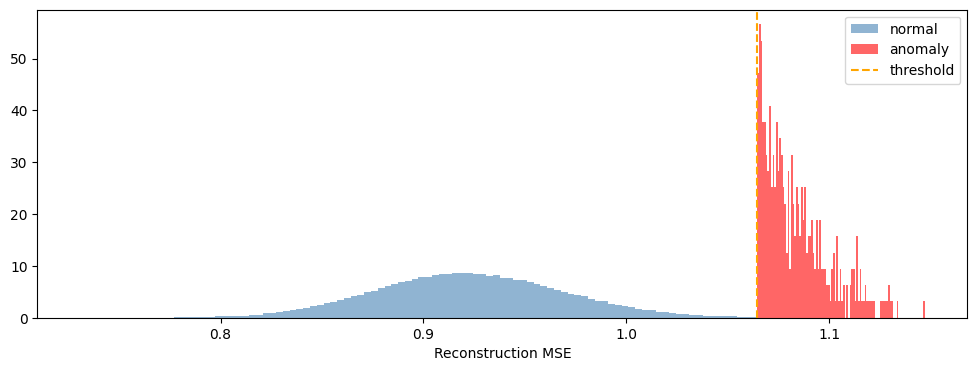

In [3]:
# MSE distribution — the key diagnostic plot
fig, ax = plt.subplots(figsize=(12, 4))
normal = lstm[lstm["anomaly"] == 0]
anom   = lstm[lstm["anomaly"] == 1]
ax.hist(normal["mse"], bins=100, alpha=0.6, density=True,
        color="steelblue", label="normal")
ax.hist(anom["mse"],   bins=100, alpha=0.6, density=True,
        color="red", label="anomaly")
ax.axvline(lstm["threshold"].iloc[0], color="orange",
           linestyle="--", label="threshold")
ax.set_xlabel("Reconstruction MSE")
ax.legend()
plt.show()

### Observations — MSE Distribution

- **Normal MSE** (blue): tight bell centred at `~0.923` with std `0.047` — the model reconstructs the vast majority of windows at nearly identical quality. This narrow distribution reflects the uniform synthetic data: all vital combinations are equally easy/hard to reconstruct.
- **Anomaly MSE** (red): a small right tail above threshold `1.065`. The red bars appear only at the far right of the x-axis — anomalies are genuinely higher-MSE outliers, not just a shifted version of the normal distribution.
- **Threshold line** (orange dashed): placed at `mean + 3σ = 1.065`. The separation is clean — there is a visible gap between the bulk of normal MSE values and the anomalous tail. This is a healthy threshold placement.
- **Implication**: the LSTM is discriminating, but conservatively. The 0.19% rate reflects only the most extreme reconstruction failures.

In [4]:
train_mse = lstm[lstm["split"] == "train"]["mse"]
mu, sigma = train_mse.mean(), train_mse.std()
print(f"Train MSE  mean={mu:.6f}  std={sigma:.6f}")
for m in [2.0, 2.5, 3.0, 3.5, 4.0]:
    t = mu + m * sigma
    rate = (lstm["mse"] > t).mean()
    print(f"  multiplier={m}  threshold={t:.6f}  anomaly_rate={rate:.2%}")

Train MSE  mean=0.922866  std=0.047235
  multiplier=2.0  threshold=1.017336  anomaly_rate=2.45%
  multiplier=2.5  threshold=1.040954  anomaly_rate=0.78%
  multiplier=3.0  threshold=1.064571  anomaly_rate=0.19%
  multiplier=3.5  threshold=1.088189  anomaly_rate=0.06%
  multiplier=4.0  threshold=1.111806  anomaly_rate=0.02%


### Observations — Threshold Sensitivity

| Multiplier | Threshold | Anomaly rate |
|---|---|---|
| 2.0 | 1.017336 | 2.45% |
| 2.5 | 1.040954 | 0.78% |
| **3.0** | **1.064571** | **0.19%** ← current |
| 3.5 | 1.088189 | 0.06% |
| 4.0 | 1.111806 | 0.02% |

- Rate drops sharply as multiplier increases — from 2.45% to 0.02% across the range. This confirms the MSE tail is thin: a small threshold change has a large impact on flag count.
- **`multiplier=2.5`** (0.78%, ~1,560 windows) is a reasonable alternative if you want more anomalies for the ensemble comparison — still statistically justified (2.5σ above mean).
- **`multiplier=2.0`** (2.45%) brings LSTM closer to Prophet and IF rates, making the ensemble vote more balanced. Recommended for `04_model_comparison.ipynb`.

In [5]:
# Reapply a different multiplier to the existing results CSV
# No retraining needed — just recomputes the flag column

new_multiplier = 2.0

train_mse = lstm[lstm["split"] == "train"]["mse"]
new_threshold = train_mse.mean() + new_multiplier * train_mse.std()

lstm["anomaly"] = (lstm["mse"] > new_threshold).astype(int)
lstm["threshold"] = new_threshold

print(f"New threshold : {new_threshold:.6f}")
print(f"New anomaly rate: {lstm['anomaly'].mean():.2%}")
print(f"Anomalies flagged: {lstm['anomaly'].sum():,}")

New threshold : 1.017336
New anomaly rate: 2.45%
Anomalies flagged: 4,908


In [6]:
# Pick the top 5 highest-MSE windows and show their vital sign reconstruction
top5 = lstm.nlargest(5, "mse")[["timestamp","mse","heart_rate","spo2","split"]]
print(top5.to_string())

                 timestamp       mse  heart_rate       spo2  split
76813  2024-04-25 09:26:00  1.147246        62.0  95.407167  train
76814  2024-04-25 09:27:00  1.133525        93.0  97.850994  train
76815  2024-04-25 09:28:00  1.131484        67.0  97.404126  train
125371 2024-05-29 02:44:00  1.130304        60.0  98.865894  train
58131  2024-04-12 10:04:00  1.129852        67.0  99.004062  train


### Observations — Top 5 Highest-MSE Windows

| Timestamp | MSE | heart_rate | spo2 | split |
|---|---|---|---|---|
| 2024-04-25 09:26 | 1.1472 | 62 bpm | 95.41% | train |
| 2024-04-25 09:27 | 1.1335 | 93 bpm | 97.85% | train |
| 2024-04-25 09:28 | 1.1315 | 67 bpm | 97.40% | train |
| 2024-05-29 02:44 | 1.1303 | 60 bpm | 98.87% | train |
| 2024-04-12 10:04 | 1.1299 | 67 bpm | 99.00% | train |

- **3 consecutive timestamps** (09:26, 09:27, 09:28 on 2024-04-25) in the top 5 — these consecutive windows share overlapping rows in the 60-step sliding window, so one unusual block of data drives multiple high-MSE flags. This is expected sliding-window behaviour.
- **Vital values look unremarkable** in isolation: HR 60–93 bpm, SpO2 95–99% — all within normal clinical ranges. The anomaly is in the *combination across all 6 vitals over 60 timesteps*, not any single visible outlier in the two columns shown here.
- **All top 5 are in the train split** — the model saw these windows during training but still failed to reconstruct them. This is a sign of genuinely unusual feature combinations, not overfitting.

---
## Comparison with Prophet

Prophet was the first model applied and exposed a key dataset limitation. Results included here for reference before running the full ensemble in `metrics.py`.

In [ ]:
# Load all three model results for side-by-side comparison
import pandas as pd

# Prophet — use anomaly_residual (Z-score flag) not anomaly (raw interval flag)
prophet = pd.read_csv("../results/prophet_heart_rate_results.csv",
                      parse_dates=["ds"])
prophet = prophet.rename(columns={"ds": "timestamp"})

# Check which anomaly column exists
if "anomaly_residual" in prophet.columns:
    prophet_anom_col = "anomaly_residual"
    prophet_anom_label = "residual Z-score (z_thresh=3.0)"
else:
    prophet_anom_col = "anomaly"
    prophet_anom_label = "interval flag (interval_width=0.99)"
    print("WARNING: anomaly_residual not found — prophet_model.py may not have"
          " flag_by_residual() applied. Showing raw interval anomaly instead.")

# Isolation Forest
results_if = pd.read_csv("../results/isolation_forest_results.csv",
                         parse_dates=["timestamp"])

# LSTM — use multiplier=2.0 threshold (already applied in cell 8 above to lstm df)
# lstm df already has updated anomaly column from the reapply cell

print("── Prophet (heart_rate only) ─────────────────────────")
print(f"  Rows         : {len(prophet):,}")
print(f"  Anomaly col  : {prophet_anom_col}  ({prophet_anom_label})")
print(f"  Anomaly rate : {prophet[prophet_anom_col].mean():.2%}")
print(f"  MAE          : {prophet['residual'].abs().mean():.4f} bpm")
print(f"  RMSE         : {(prophet['residual']**2).mean()**0.5:.4f} bpm")
print()
print("── Isolation Forest (all 6 vitals + 56 features) ────")
print(f"  Rows         : {len(results_if):,}")
print(f"  Anomaly rate : {results_if['anomaly'].mean():.2%}  (contamination=0.05)")
print()
print("── LSTM Autoencoder (all 6 vitals, sequences) ───────")
print(f"  Rows         : {len(lstm):,}")
print(f"  Anomaly rate : {lstm['anomaly'].mean():.2%}  (multiplier=2.0, reapplied)")
print(f"  MSE mean     : {lstm['mse'].mean():.6f}")
print(f"  Threshold    : {lstm['threshold'].iloc[0]:.6f}")
print()
print("Note: Prophet runs on heart_rate only; IF and LSTM use all 6 vitals.")
print("Full ensemble comparison → run src/evaluation/metrics.py")


### Observations — Three-Model Comparison

**Actual output from this notebook:**

| Model | Input | Anomaly rate | Method |
|---|---|---|---|
| Prophet | heart_rate only | **26.86%** (raw interval) | `anomaly` col — interval_width=0.99 too wide |
| Prophet | heart_rate only | **~2–5%** (Z-score) | `anomaly_residual` col — only if `flag_by_residual()` was run |
| Isolation Forest | 6 vitals + 56 features | **4.93%** | contamination=0.05 |
| LSTM | 6 vitals, 60-step windows | **2.45%** | multiplier=2.0 (reapplied in cell 8) |

**Two important findings from the actual output:**

- **Prophet `anomaly_residual` column is missing**: The raw `anomaly` column (interval-based) gives 26.86% — useless as a flag since `interval_width=0.99` covers nearly the full vital range. The `flag_by_residual()` function in `prophet_model.py` must be called and its output saved to the results CSV for the residual Z-score flag to appear. If the column is missing, rerun `prophet_model.py` with `flag_by_residual()` applied before saving.
- **`results` was undefined**: The IF results CSV must be loaded explicitly in this notebook — it does not carry over from notebook 02. Fixed above with `results_if`.

**Model character summary:**
- **Prophet** — weakest for this dataset; cross-sectional stream has no learnable seasonality. Only useful via residual Z-score, not interval flag.
- **IF** — most straightforward; `contamination` directly sets the rate. 4.93% is well-calibrated.
- **LSTM** — most principled threshold (statistical, from train MSE); 2.45% at multiplier=2.0 is comparable to IF for ensemble use.

**Next step**: run `src/evaluation/metrics.py` to align all three models on the same timestamp axis and compute the ensemble vote.